In [1]:
import pandas as pd
import numpy as np 

In [2]:
data = {
    'volume': [9.8, 9.9, 10.0, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6],
    'pH': [7.1, 7.4, 8.2, np.nan, 10.5, 10.8, 11.0, 11.5, 11.9]
}

df = pd.DataFrame(data)

In [3]:
print("Before Cleaning")
print(df)

Before Cleaning
   volume    pH
0     9.8   7.1
1     9.9   7.4
2    10.0   8.2
3    10.1   NaN
4    10.2  10.5
5    10.3  10.8
6    10.4  11.0
7    10.5  11.5
8    10.6  11.9


In [4]:
# data cleaning using interpolation to interploate the missing value of pH
df['pH'] = df['pH'].interpolate()
print("Data After cleaning")
print(df)

Data After cleaning
   volume     pH
0     9.8   7.10
1     9.9   7.40
2    10.0   8.20
3    10.1   9.35
4    10.2  10.50
5    10.3  10.80
6    10.4  11.00
7    10.5  11.50
8    10.6  11.90


In [5]:
# calculating the first derivatives 
# using the diff() function allows you to get the difference between the current row and the row above
df['dpH'] = df['pH'].diff()
df['dvol'] = df['volume'].diff()
print(df)

   volume     pH   dpH  dvol
0     9.8   7.10   NaN   NaN
1     9.9   7.40  0.30   0.1
2    10.0   8.20  0.80   0.1
3    10.1   9.35  1.15   0.1
4    10.2  10.50  1.15   0.1
5    10.3  10.80  0.30   0.1
6    10.4  11.00  0.20   0.1
7    10.5  11.50  0.50   0.1
8    10.6  11.90  0.40   0.1


In [6]:
# Calculating the actual derivative

df['dpH_dvol'] = df['dpH'] / df['dvol']
print(df)

   volume     pH   dpH  dvol  dpH_dvol
0     9.8   7.10   NaN   NaN       NaN
1     9.9   7.40  0.30   0.1       3.0
2    10.0   8.20  0.80   0.1       8.0
3    10.1   9.35  1.15   0.1      11.5
4    10.2  10.50  1.15   0.1      11.5
5    10.3  10.80  0.30   0.1       3.0
6    10.4  11.00  0.20   0.1       2.0
7    10.5  11.50  0.50   0.1       5.0
8    10.6  11.90  0.40   0.1       4.0


In [7]:
# getting the index of the equivalence 
ep_index = df['dpH_dvol'].idxmax()
print(ep_index)

3


In [8]:
# getting the volume and oh of the equivalence point
vol_point = df.loc[ep_index, 'volume']
ph_point = df.loc[ep_index, 'pH']
print(vol_point)
print(ph_point)

10.1
9.35


In [11]:
print(f"The equivalence point is at volume: {vol_point} mL and pH: {ph_point}")

The equivalence point is at volume: 10.1 mL and pH: 9.35


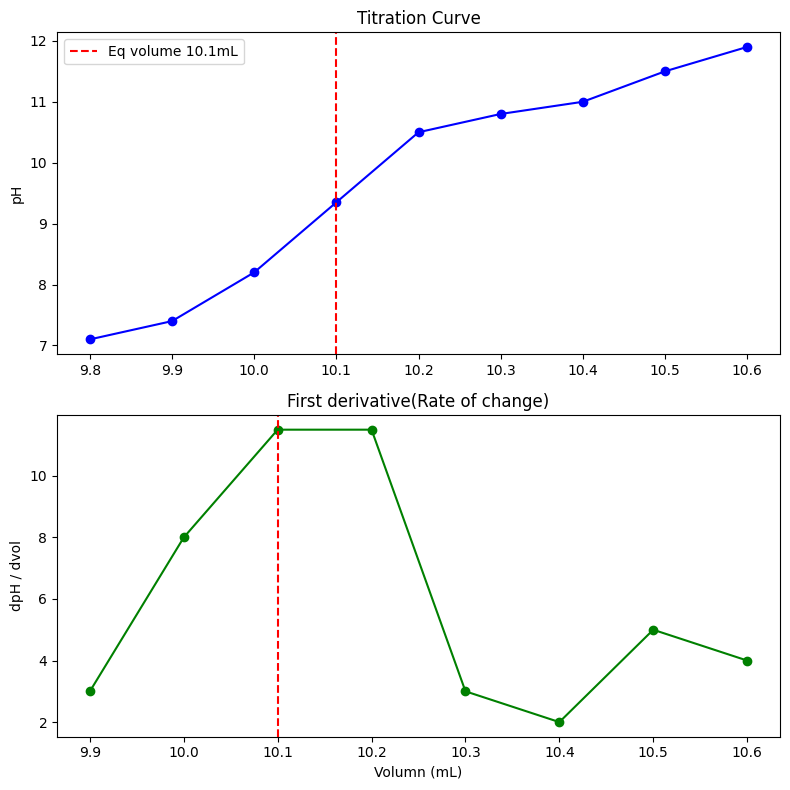

In [17]:
# visualising the data using matplotlib
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols= 1, figsize=(8, 8))

ax1.plot(df['volume'], df['pH'], marker='o', color='blue')
ax1.set_title('Titration Curve')
ax1.set_ylabel("pH")

# drawing a vertical line at the equivalece point
ax1.axvline(x=vol_point, color='red', linestyle='--', label=f'Eq volume {vol_point}mL')
ax1.legend()

ax2.plot(df['volume'], df['dpH_dvol'], marker='o', color='green')
ax2.set_title('First derivative(Rate of change)')
ax2.set_xlabel('Volumn (mL)')
ax2.set_ylabel('dpH / dvol')

# drawing a vertucal line
ax2.axvline(x=vol_point, color='red', linestyle='--')
plt.tight_layout()
plt.show()